# MIL as Document-Level Classifier

This notebook evaluates the MIL model not as a span localizer, but as a document-level classifier. It compares MIL predictions against the ground-truth `Inappropriateness` labels and against the Ziegenbein document-level classifier that is already stored in the prepared splits.

After this introductory note, the baseline classifier is referred to as `original_classifier` throughout the notebook. All generated tables and plots are written into the already existing `OUTPUT_DIR` variable.


In [1]:
import warnings
import sys
import os
import re
import json
import random
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
)

SCIPY_AVAILABLE = True

CURRENT_DIR = Path.cwd()

if (CURRENT_DIR / "src").is_dir():
    PROJECT_ROOT = CURRENT_DIR
elif (CURRENT_DIR.parent / "src").is_dir():
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    raise FileNotFoundError(
        "Could not locate the project root containing the 'src' directory."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import load_prepared_splits

In [2]:
BASE_DIR = Path.cwd().parent
RESULT_DIR = BASE_DIR / "results"
OUTPUT_DIR = RESULT_DIR / "evaluation/mil"
TABLE_DIR = OUTPUT_DIR / "mil_classifier_evaluation_tables"
PLOT_DIR = OUTPUT_DIR / "mil_classifier_evaluation_plots"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
df_all, train_df, val_df, test_df = load_prepared_splits()
mil_arguments = pd.read_csv(RESULT_DIR / "mil_results/mil_span_run_singles/mil_results_final/mil_final_all_splits_pool=topk_noisy_or__topk=3__spans=15__stride=4__freeze=True_argument_level.csv")
mil_summary = pd.read_csv(RESULT_DIR / "mil_results/mil_span_run_singles/mil_results_final/mil_final_all_splits_pool=topk_noisy_or__topk=3__spans=15__stride=4__freeze=True_confusion_summary.csv")

## 3. Build a unified evaluation dataframe

This cell merges the MIL outputs with the prepared split dataframe via `global_row_id`. It standardizes the following columns:

- `y_true`: ground-truth inappropriateness label
- `original_classifier_probability`: original classifier probability for the inappropriate class
- `original_classifier_prediction`: original classifier binary prediction
- `mil_probability`: MIL bag-level probability
- `mil_prediction_0_5`: MIL prediction using a fixed threshold of 0.5


In [4]:
def find_first_existing(df, candidates, required=True, label="column"):
    for col in candidates:
        if col in df.columns:
            return col
    if required:
        raise KeyError(f"Could not find {label}. Tried: {candidates}")
    return None


def normalize_binary_label(value):
    """Normalize common 0/1 or label string formats to integer 0/1."""
    if pd.isna(value):
        return np.nan

    if isinstance(value, (bool, np.bool_)):
        return int(value)

    if isinstance(value, (int, np.integer)):
        if value in [0, 1]:
            return int(value)

    if isinstance(value, (float, np.floating)):
        if value in [0.0, 1.0]:
            return int(value)

    s = str(value).strip().lower()

    positive_values = {
        "1", "true", "yes", "label_1", "inappropriate", "inappropriateness",
        "positive", "pos", "inappropriate_label", "inappropriateness_label",
    }
    negative_values = {
        "0", "false", "no", "label_0", "appropriate", "negative", "neg",
        "appropriate_label",
    }

    if s in positive_values:
        return 1
    if s in negative_values:
        return 0

    return np.nan


def normalize_prediction_series(series, fallback_probability=None, threshold=0.5):
    normalized = series.apply(normalize_binary_label)

    if normalized.notna().all():
        return normalized.astype(int)

    if fallback_probability is None:
        raise ValueError(
            "Prediction labels could not be normalized and no fallback probability was provided."
        )

    warnings.warn(
        "Some prediction labels could not be normalized. Falling back to probability threshold."
    )
    return (fallback_probability.astype(float) >= threshold).astype(int)


GT_COL = "Inappropriateness"
ORIGINAL_PROB_COL = "p_inappropriate_original"
ORIGINAL_PRED_COL = "predicted_label"

MIL_PROB_COL = find_first_existing(
    mil_arguments,
    candidates=[
        "mil_probability",
        "bag_probability",
        "predicted_probability",
        "prediction_probability",
    ],
    label="MIL probability column",
)

print("Using MIL probability column:", MIL_PROB_COL)

prepared_cols = [
    "global_row_id",
    "post_id",
    "source_dataset",
    "issue",
    "post_text",
    "split",
    "text_norm",
    GT_COL,
    ORIGINAL_PROB_COL,
    ORIGINAL_PRED_COL,
    "predicted_score",
    "confusion_type",
    "is_true_positive",
    "is_false_negative",
    "is_false_positive",
    "is_true_negative",
]
prepared_cols = [col for col in prepared_cols if col in df_all.columns]

mil_cols = [
    "global_row_id",
    MIL_PROB_COL,
    "mil_predicted_label",
    "mil_confusion_type",
    "pooling_mode",
    "top_k",
    "span_lengths_label",
    "span_length_single",
    "stride",
    "freeze_encoder",
    "config_id",
]
mil_cols = [col for col in mil_cols if col in mil_arguments.columns]

# Avoid duplicate non-key columns during merge.
mil_cols = ["global_row_id"] + [col for col in mil_cols if col != "global_row_id" and col not in prepared_cols]

eval_df = df_all[prepared_cols].merge(
    mil_arguments[mil_cols],
    on="global_row_id",
    how="inner",
    validate="one_to_one",
)

eval_df["y_true"] = eval_df[GT_COL].apply(normalize_binary_label).astype(int)
eval_df["original_classifier_probability"] = eval_df[ORIGINAL_PROB_COL].astype(float)
eval_df["original_classifier_prediction"] = normalize_prediction_series(
    eval_df[ORIGINAL_PRED_COL],
    fallback_probability=eval_df["original_classifier_probability"],
    threshold=0.5,
)
eval_df["original_classifier_correct"] = eval_df["original_classifier_prediction"].eq(eval_df["y_true"])

eval_df["mil_probability"] = eval_df[MIL_PROB_COL].astype(float)
eval_df["mil_prediction_0_5"] = (eval_df["mil_probability"] >= 0.5).astype(int)
eval_df["mil_correct_0_5"] = eval_df["mil_prediction_0_5"].eq(eval_df["y_true"])

print("Evaluation dataframe:", eval_df.shape)
print("Splits:")
print(eval_df["split"].value_counts())

EVAL_DF_PATH = TABLE_DIR / "mil_classifier_evaluation_dataframe.csv"
eval_df.to_csv(EVAL_DF_PATH, index=False)
print("Saved:", EVAL_DF_PATH)

display(eval_df.head())


Using MIL probability column: mil_probability
Evaluation dataframe: (2191, 32)
Splits:
split
train         1533
test           438
validation     220
Name: count, dtype: int64
Saved: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/evaluation/mil/mil_classifier_evaluation_tables/mil_classifier_evaluation_dataframe.csv


,global_row_id,post_id,source_dataset,issue,post_text,split,text_norm,Inappropriateness,p_inappropriate_original,predicted_label,...,span_length_single,stride,freeze_encoder,config_id,y_true,original_classifier_probability,original_classifier_prediction,original_classifier_correct,mil_prediction_0_5,mil_correct_0_5
0,0,1,0,Is the school uniform a good or bad idea:,"people cant be forced to wear school uniforms,...",train,"people cant be forced to wear school uniforms,...",1,0.997032,LABEL_1,...,15,4,True,pool=topk_noisy_or__topk=3__spans=15__stride=4...,1,0.997032,1,True,0,False
1,1,2,0,Firefox vs internet explorer:,"That form of argument degrades this forum, and...",train,"That form of argument degrades this forum, and...",1,0.998218,LABEL_1,...,15,4,True,pool=topk_noisy_or__topk=3__spans=15__stride=4...,1,0.998218,1,True,1,True
2,2,3,0,If your spouse committed murder and he or she ...,I wouldnt turn her in becuase she is my wife. ...,train,I wouldnt turn her in becuase she is my wife. ...,0,0.030317,LABEL_0,...,15,4,True,pool=topk_noisy_or__topk=3__spans=15__stride=4...,0,0.030317,0,True,0,True
3,3,4,0,If your spouse committed murder and he or she ...,No I wouldn't turn in my spouse. Just because ...,train,No I wouldn't turn in my spouse. Just because ...,1,0.998705,LABEL_1,...,15,4,True,pool=topk_noisy_or__topk=3__spans=15__stride=4...,1,0.998705,1,True,0,False
4,4,5,0,Tv is better than books:,TV is terrible. Except for Spongebob maybe. Th...,train,TV is terrible. Except for Spongebob maybe. Th...,1,0.998405,LABEL_1,...,15,4,True,pool=topk_noisy_or__topk=3__spans=15__stride=4...,1,0.998405,1,True,0,False


## 4. Compute classifier metrics

This cell computes standard document-level classification metrics for the original classifier and for MIL with the fixed decision threshold 0.5.


In [5]:
def safe_roc_auc(y_true, y_prob):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_prob)


def safe_average_precision(y_true, y_prob):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return average_precision_score(y_true, y_prob)


def compute_metric_row(df, method_name, pred_col, prob_col, split_name, threshold):
    y_true = df["y_true"].astype(int).to_numpy()
    y_pred = df[pred_col].astype(int).to_numpy()
    y_prob = df[prob_col].astype(float).to_numpy()

    return {
        "split": split_name,
        "method": method_name,
        "n": int(len(df)),
        "positive_support": int(np.sum(y_true == 1)),
        "negative_support": int(np.sum(y_true == 0)),
        "predicted_positive_rate": float(np.mean(y_pred == 1)),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": safe_roc_auc(y_true, y_prob),
        "average_precision": safe_average_precision(y_true, y_prob),
        "brier_score": brier_score_loss(y_true, y_prob),
        "threshold": threshold,
    }


method_specs = [
    {
        "method_name": "original_classifier",
        "pred_col": "original_classifier_prediction",
        "prob_col": "original_classifier_probability",
        "threshold": 0.5,
    },
    {
        "method_name": "MIL@0.5",
        "pred_col": "mil_prediction_0_5",
        "prob_col": "mil_probability",
        "threshold": 0.5,
    },
]

split_order = [split for split in ["train", "validation", "test"] if split in eval_df["split"].unique()]
metric_rows = []

for split_name in split_order:
    split_df = eval_df[eval_df["split"] == split_name].copy()

    for spec in method_specs:
        metric_rows.append(
            compute_metric_row(
                split_df,
                method_name=spec["method_name"],
                pred_col=spec["pred_col"],
                prob_col=spec["prob_col"],
                split_name=split_name,
                threshold=spec["threshold"],
            )
        )

for spec in method_specs:
    metric_rows.append(
        compute_metric_row(
            eval_df,
            method_name=spec["method_name"],
            pred_col=spec["pred_col"],
            prob_col=spec["prob_col"],
            split_name="all",
            threshold=spec["threshold"],
        )
    )

metrics_df = pd.DataFrame(metric_rows)

METRICS_PATH = TABLE_DIR / "classifier_metrics_by_split.csv"
metrics_df.to_csv(METRICS_PATH, index=False)

print("Saved:", METRICS_PATH)
display(metrics_df)


Saved: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/evaluation/mil/mil_classifier_evaluation_tables/classifier_metrics_by_split.csv


,split,method,n,positive_support,negative_support,predicted_positive_rate,accuracy,precision,recall,f1,roc_auc,average_precision,brier_score,threshold
0,train,original_classifier,1533,833,700,0.543379,0.937378,0.942377,0.942377,0.942377,0.973229,0.971829,0.054609,0.5
1,train,MIL@0.5,1533,833,700,0.512068,0.779517,0.815287,0.768307,0.791100,0.857833,0.879618,0.180998,0.5
2,validation,original_classifier,220,124,96,0.536364,0.700000,0.745763,0.709677,0.727273,0.756384,0.778569,0.283717,0.5
3,validation,MIL@0.5,220,124,96,0.477273,0.722727,0.800000,0.677419,0.733624,0.767641,0.799578,0.233043,0.5
4,test,original_classifier,438,225,213,0.586758,0.748858,0.723735,0.826667,0.771784,0.785874,0.748761,0.239249,0.5
5,test,MIL@0.5,438,225,213,0.520548,0.668950,0.675439,0.684444,0.679912,0.741158,0.786906,0.272393,0.5
6,all,original_classifier,2191,1182,1009,0.551346,0.875856,0.876656,0.895939,0.886192,0.916615,0.906655,0.114525,0.5
7,all,MIL@0.5,2191,1182,1009,0.510269,0.751712,0.785331,0.742809,0.763478,0.824871,0.851888,0.204495,0.5


## 5. Confusion matrices

This cell stores confusion-matrix counts for both classifiers. Rows follow the binary convention `0 = appropriate` and `1 = inappropriate`.


In [6]:
def compute_confusion_row(df, method_name, pred_col, split_name):
    y_true = df["y_true"].astype(int).to_numpy()
    y_pred = df[pred_col].astype(int).to_numpy()

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    return {
        "split": split_name,
        "method": method_name,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "n": int(len(df)),
    }


confusion_rows = []

for split_name in split_order:
    split_df = eval_df[eval_df["split"] == split_name].copy()

    for spec in method_specs:
        confusion_rows.append(
            compute_confusion_row(
                split_df,
                method_name=spec["method_name"],
                pred_col=spec["pred_col"],
                split_name=split_name,
            )
        )

for spec in method_specs:
    confusion_rows.append(
        compute_confusion_row(
            eval_df,
            method_name=spec["method_name"],
            pred_col=spec["pred_col"],
            split_name="all",
        )
    )

confusion_df = pd.DataFrame(confusion_rows)

CONFUSION_PATH = TABLE_DIR / "confusion_matrices_by_split.csv"
confusion_df.to_csv(CONFUSION_PATH, index=False)

print("Saved:", CONFUSION_PATH)
display(confusion_df)


Saved: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/evaluation/mil/mil_classifier_evaluation_tables/confusion_matrices_by_split.csv


,split,method,tn,fp,fn,tp,n
0,train,original_classifier,652,48,48,785,1533
1,train,MIL@0.5,555,145,193,640,1533
2,validation,original_classifier,66,30,36,88,220
3,validation,MIL@0.5,75,21,40,84,220
4,test,original_classifier,142,71,39,186,438
5,test,MIL@0.5,139,74,71,154,438
6,all,original_classifier,860,149,123,1059,2191
7,all,MIL@0.5,769,240,304,878,2191


## 6. Paired comparison

This cell compares the two classifiers on the same arguments. It counts where both are correct, where only one is correct, and where both are wrong.


In [7]:
def paired_comparison(df, split_name):
    original_correct = df["original_classifier_prediction"].eq(df["y_true"])
    mil_correct = df["mil_prediction_0_5"].eq(df["y_true"])

    return {
        "split": split_name,
        "n": int(len(df)),
        "both_correct": int((original_correct & mil_correct).sum()),
        "original_only_correct": int((original_correct & ~mil_correct).sum()),
        "mil_only_correct": int((~original_correct & mil_correct).sum()),
        "both_wrong": int((~original_correct & ~mil_correct).sum()),
        "both_correct_rate": float((original_correct & mil_correct).mean()),
        "original_only_correct_rate": float((original_correct & ~mil_correct).mean()),
        "mil_only_correct_rate": float((~original_correct & mil_correct).mean()),
        "both_wrong_rate": float((~original_correct & ~mil_correct).mean()),
    }


paired_rows = []

for split_name in split_order:
    split_df = eval_df[eval_df["split"] == split_name].copy()
    paired_rows.append(paired_comparison(split_df, split_name=split_name))

paired_rows.append(paired_comparison(eval_df, split_name="all"))

paired_df = pd.DataFrame(paired_rows)

PAIRED_PATH = TABLE_DIR / "paired_original_classifier_vs_mil_0_5.csv"
paired_df.to_csv(PAIRED_PATH, index=False)

print("Saved:", PAIRED_PATH)
display(paired_df)


Saved: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/evaluation/mil/mil_classifier_evaluation_tables/paired_original_classifier_vs_mil_0_5.csv


,split,n,both_correct,original_only_correct,mil_only_correct,both_wrong,both_correct_rate,original_only_correct_rate,mil_only_correct_rate,both_wrong_rate
0,train,1533,1150,287,45,51,0.750163,0.187215,0.029354,0.033268
1,validation,220,123,31,36,30,0.559091,0.140909,0.163636,0.136364
2,test,438,243,85,50,60,0.554795,0.194064,0.114155,0.136986
3,all,2191,1516,403,131,141,0.691921,0.183934,0.059790,0.064354


## 7. Error analysis by original-classifier confusion type

The prepared splits already contain `confusion_type` for the original classifier. This cell checks whether MIL recovers some false negatives or avoids some false positives according to that grouping.


In [8]:
error_analysis_df = eval_df.copy()

confusion_type_analysis = (
    error_analysis_df
    .groupby(["split", "confusion_type"])
    .agg(
        n=("global_row_id", "nunique"),
        gold_positive_rate=("y_true", "mean"),
        mean_original_classifier_probability=("original_classifier_probability", "mean"),
        mean_mil_probability=("mil_probability", "mean"),
        original_classifier_accuracy=("original_classifier_correct", "mean"),
        mil_accuracy_0_5=("mil_correct_0_5", "mean"),
        mil_predicted_positive_rate_0_5=("mil_prediction_0_5", "mean"),
    )
    .reset_index()
    .sort_values(["split", "confusion_type"])
)

CONFUSION_TYPE_ANALYSIS_PATH = TABLE_DIR / "mil_performance_by_original_classifier_confusion_type.csv"
confusion_type_analysis.to_csv(CONFUSION_TYPE_ANALYSIS_PATH, index=False)

print("Saved:", CONFUSION_TYPE_ANALYSIS_PATH)
display(confusion_type_analysis)


Saved: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/evaluation/mil/mil_classifier_evaluation_tables/mil_performance_by_original_classifier_confusion_type.csv


,split,confusion_type,n,gold_positive_rate,mean_original_classifier_probability,mean_mil_probability,original_classifier_accuracy,mil_accuracy_0_5,mil_predicted_positive_rate_0_5
0,test,FN,39,1.0,0.049637,0.442743,0.0,0.410256,0.410256
1,test,FP,71,0.0,0.971583,0.539303,0.0,0.478873,0.521127
2,test,TN,142,0.0,0.037214,0.265131,1.0,0.739437,0.260563
3,test,TP,186,1.0,0.981553,0.746989,1.0,0.741935,0.741935
4,train,FN,48,1.0,0.115294,0.314211,0.0,0.291667,0.291667
5,train,FP,48,0.0,0.915787,0.362953,0.0,0.645833,0.354167
6,train,TN,652,0.0,0.030158,0.209732,1.0,0.803681,0.196319
7,train,TP,785,1.0,0.990161,0.783878,1.0,0.797452,0.797452
8,validation,FN,36,1.0,0.040577,0.425958,0.0,0.416667,0.416667
9,validation,FP,30,0.0,0.968821,0.349691,0.0,0.700000,0.300000


## 8. Save disagreement examples

This cell saves example subsets that are useful for qualitative inspection.


In [9]:
example_df = eval_df.copy()

example_df["comparison_case"] = np.select(
    [
        example_df["original_classifier_correct"] & example_df["mil_correct_0_5"],
        example_df["original_classifier_correct"] & ~example_df["mil_correct_0_5"],
        ~example_df["original_classifier_correct"] & example_df["mil_correct_0_5"],
        ~example_df["original_classifier_correct"] & ~example_df["mil_correct_0_5"],
    ],
    [
        "both_correct",
        "original_only_correct",
        "mil_only_correct",
        "both_wrong",
    ],
    default="unknown",
)

example_cols = [
    "global_row_id",
    "post_id",
    "split",
    "issue",
    "post_text",
    "text_norm",
    "y_true",
    "original_classifier_probability",
    "original_classifier_prediction",
    "mil_probability",
    "mil_prediction_0_5",
    "confusion_type",
    "comparison_case",
]
example_cols = [col for col in example_cols if col in example_df.columns]

examples_path = TABLE_DIR / "mil_vs_original_classifier_disagreement_examples.csv"
example_df[example_cols].to_csv(examples_path, index=False)

print("Saved:", examples_path)

display(
    example_df[example_cols]
    .sort_values(["split", "comparison_case", "global_row_id"])
    .head(20)
)


Saved: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/evaluation/mil/mil_classifier_evaluation_tables/mil_vs_original_classifier_disagreement_examples.csv


,global_row_id,post_id,split,issue,post_text,text_norm,y_true,original_classifier_probability,original_classifier_prediction,mil_probability,mil_prediction_0_5,confusion_type,comparison_case
1754,1754,8,test,Tv is better than books:,I thick that book are better than TV is it is ...,I thick that book are better than TV is it is ...,1,0.997475,1,0.886028,1,TP,both_correct
1755,1755,9,test,Tv is better than books:,Books enlighten the soul. Books don't destroy ...,Books enlighten the soul. Books don't destroy ...,1,0.998255,1,0.754180,1,TP,both_correct
1757,1757,15,test,Is it better to have a lousy father or to be f...,"Honestly, I'd rather be completely fatherless,...","Honestly, I'd rather be completely fatherless,...",0,0.006339,0,0.048374,0,TN,both_correct
1759,1759,22,test,Evolution vs creation:,"I am a nurse and the more I studied biology, t...","I am a nurse and the more I studied biology, t...",1,0.992263,1,0.998968,1,TP,both_correct
1760,1760,25,test,Firefox vs internet explorer:,Firefox (and the extensions) leaks memory like...,Firefox (and the extensions) leaks memory like...,0,0.017569,0,0.029864,0,TN,both_correct
1763,1763,46,test,Is it better to have a lousy father or to be f...,To my knowledge people are able to change and ...,To my knowledge people are able to change and ...,0,0.043886,0,0.005763,0,TN,both_correct
1764,1764,54,test,Ban plastic water bottles:,there aint no sunshine without plastic water b...,there aint no sunshine without plastic water b...,1,0.997929,1,0.779556,1,TP,both_correct
1765,1765,60,test,India has the potential to lead the world:,how can Indians say that india don not have th...,how can Indians say that india don not have th...,1,0.996554,1,1.000000,1,TP,both_correct
1766,1766,63,test,If your spouse committed murder and he or she ...,I would say that i would turn them in because ...,I would say that i would turn them in because ...,0,0.003422,0,0.002879,0,TN,both_correct
1767,1767,65,test,Pro choice vs pro life:,The government has no place to tell a woman wh...,The government has no place to tell a woman wh...,1,0.998269,1,0.999951,1,TP,both_correct


## 9. Plot helper functions

All plots are saved to `PLOT_DIR`.


In [10]:
def save_current_plot(filename):
    path = PLOT_DIR / filename
    plt.savefig(path, dpi=200, bbox_inches="tight")
    print("Saved:", path)
    plt.show()


def plot_metric_bar(metrics_df, metric, filename, title=None):
    plot_df = metrics_df[metrics_df["split"].isin(split_order)].copy()
    pivot = plot_df.pivot(index="split", columns="method", values=metric).reindex(split_order)

    ax = pivot.plot(kind="bar", figsize=(9, 5))
    ax.set_xlabel("Split")
    ax.set_ylabel(metric)
    ax.set_title(title if title is not None else metric)
    ax.set_ylim(0, 1)
    ax.legend(title="Method")
    plt.xticks(rotation=0)
    plt.grid(axis="y", alpha=0.3)
    save_current_plot(filename)


def plot_roc_for_split(eval_df, split_name, filename):
    split_df = eval_df[eval_df["split"] == split_name].copy()

    plt.figure(figsize=(7, 6))

    for method_name, prob_col in [
        ("original_classifier", "original_classifier_probability"),
        ("MIL", "mil_probability"),
    ]:
        y_true = split_df["y_true"].to_numpy()
        y_prob = split_df[prob_col].to_numpy()

        if len(np.unique(y_true)) < 2:
            continue

        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc_value = roc_auc_score(y_true, y_prob)
        plt.plot(fpr, tpr, label=f"{method_name} (AUC={auc_value:.3f})")

    plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title(f"ROC curve: {split_name}")
    plt.legend()
    plt.grid(alpha=0.3)
    save_current_plot(filename)


def plot_precision_recall_for_split(eval_df, split_name, filename):
    split_df = eval_df[eval_df["split"] == split_name].copy()

    plt.figure(figsize=(7, 6))

    for method_name, prob_col in [
        ("original_classifier", "original_classifier_probability"),
        ("MIL", "mil_probability"),
    ]:
        y_true = split_df["y_true"].to_numpy()
        y_prob = split_df[prob_col].to_numpy()

        if len(np.unique(y_true)) < 2:
            continue

        precision, recall, _ = precision_recall_curve(y_true, y_prob)
        ap_value = average_precision_score(y_true, y_prob)
        plt.plot(recall, precision, label=f"{method_name} (AP={ap_value:.3f})")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-recall curve: {split_name}")
    plt.legend()
    plt.grid(alpha=0.3)
    save_current_plot(filename)


def plot_confusion_matrix_image(eval_df, split_name, method_name, pred_col, filename):
    split_df = eval_df[eval_df["split"] == split_name].copy()

    cm = confusion_matrix(
        split_df["y_true"].astype(int),
        split_df[pred_col].astype(int),
        labels=[0, 1],
    )

    fig, ax = plt.subplots(figsize=(5, 4))
    image = ax.imshow(cm)
    fig.colorbar(image, ax=ax)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["pred 0", "pred 1"])
    ax.set_yticklabels(["gold 0", "gold 1"])
    ax.set_xlabel("Prediction")
    ax.set_ylabel("Ground truth")
    ax.set_title(f"{method_name}: {split_name}")

    for row_idx in range(cm.shape[0]):
        for col_idx in range(cm.shape[1]):
            ax.text(col_idx, row_idx, str(cm[row_idx, col_idx]), ha="center", va="center")

    save_current_plot(filename)


## 10. Create main plots

This cell creates the main plots for the classifier comparison.


Saved: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/evaluation/mil/mil_classifier_evaluation_plots/mil_vs_original_classifier_f1_by_split.png


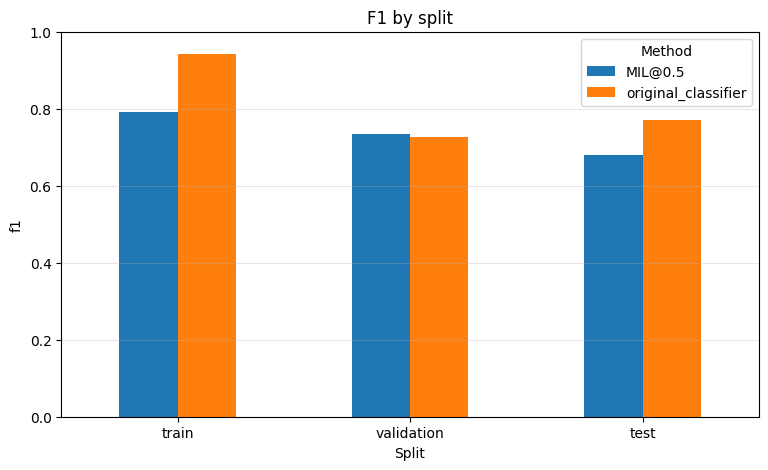

Saved: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/evaluation/mil/mil_classifier_evaluation_plots/mil_vs_original_classifier_accuracy_by_split.png


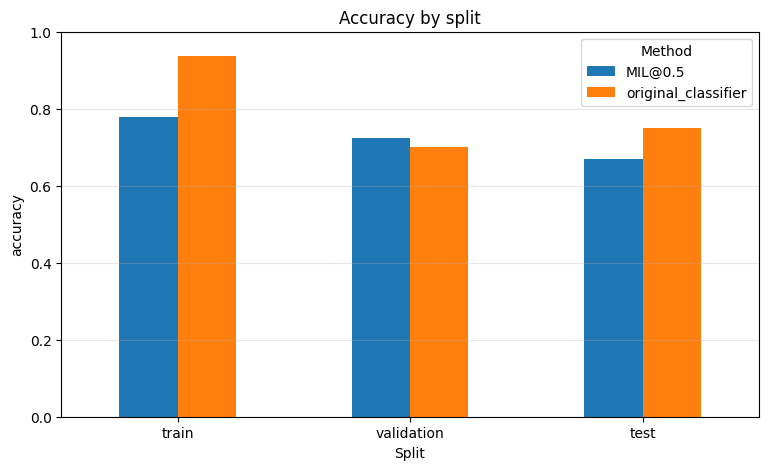

Saved: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/evaluation/mil/mil_classifier_evaluation_plots/mil_vs_original_classifier_roc_auc_by_split.png


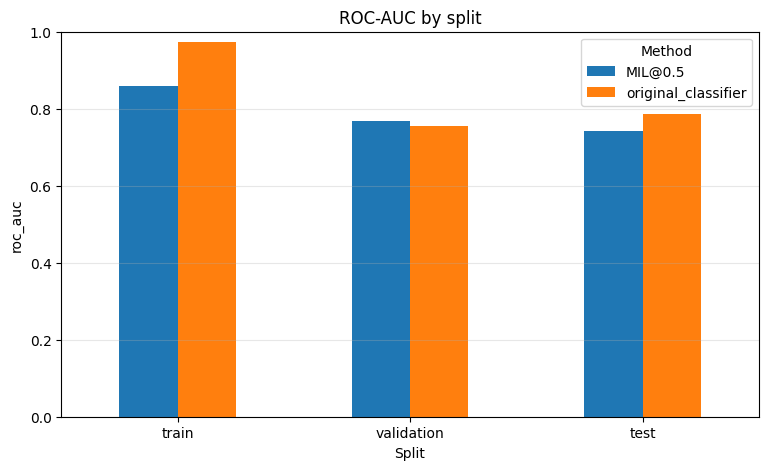

Saved: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/evaluation/mil/mil_classifier_evaluation_plots/mil_vs_original_classifier_roc_curve_test.png


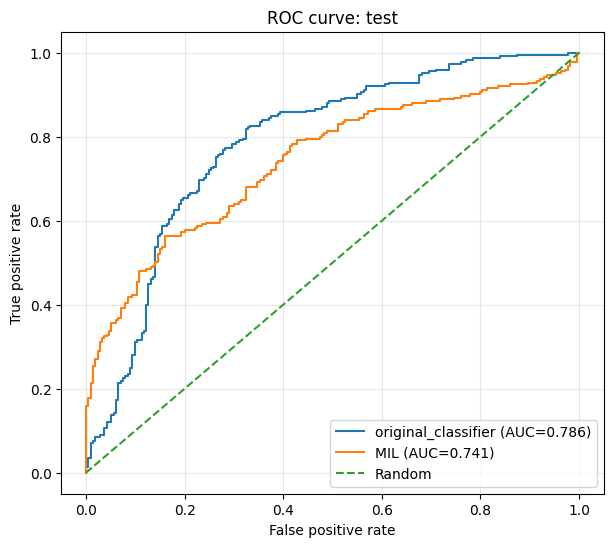

Saved: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/evaluation/mil/mil_classifier_evaluation_plots/mil_vs_original_classifier_precision_recall_curve_test.png


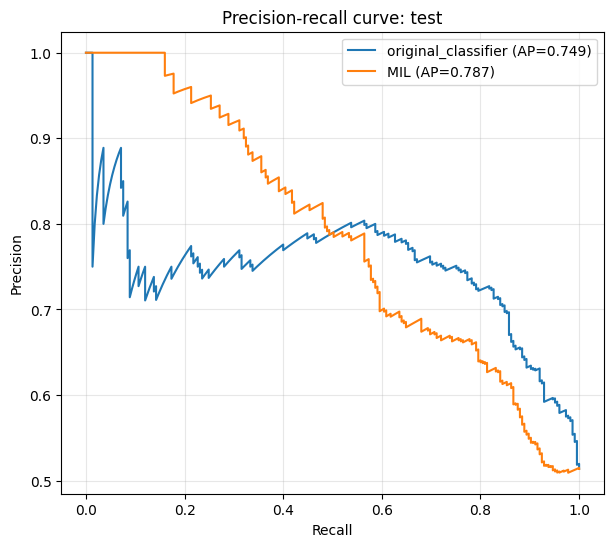

Saved: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/evaluation/mil/mil_classifier_evaluation_plots/confusion_matrix_test_original_classifier.png


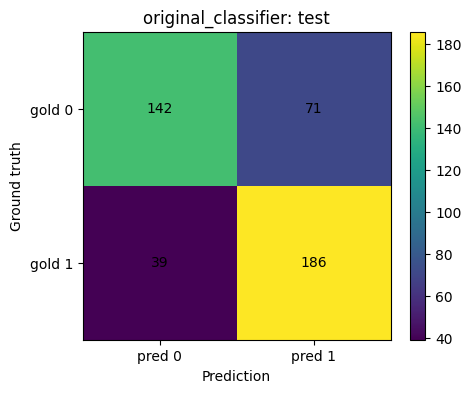

Saved: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/evaluation/mil/mil_classifier_evaluation_plots/confusion_matrix_test_mil_0_5.png


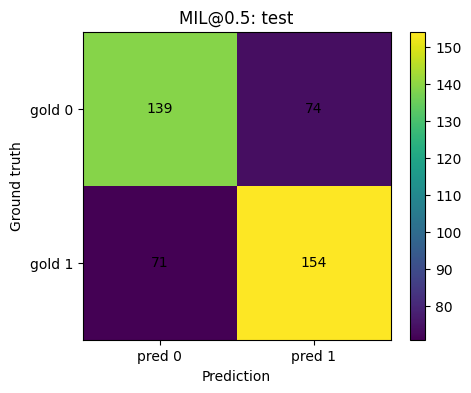

In [11]:
plot_metric_bar(
    metrics_df,
    metric="f1",
    filename="mil_vs_original_classifier_f1_by_split.png",
    title="F1 by split",
)

plot_metric_bar(
    metrics_df,
    metric="accuracy",
    filename="mil_vs_original_classifier_accuracy_by_split.png",
    title="Accuracy by split",
)

plot_metric_bar(
    metrics_df,
    metric="roc_auc",
    filename="mil_vs_original_classifier_roc_auc_by_split.png",
    title="ROC-AUC by split",
)

plot_roc_for_split(
    eval_df,
    split_name="test",
    filename="mil_vs_original_classifier_roc_curve_test.png",
)

plot_precision_recall_for_split(
    eval_df,
    split_name="test",
    filename="mil_vs_original_classifier_precision_recall_curve_test.png",
)

plot_confusion_matrix_image(
    eval_df,
    split_name="test",
    method_name="original_classifier",
    pred_col="original_classifier_prediction",
    filename="confusion_matrix_test_original_classifier.png",
)

plot_confusion_matrix_image(
    eval_df,
    split_name="test",
    method_name="MIL@0.5",
    pred_col="mil_prediction_0_5",
    filename="confusion_matrix_test_mil_0_5.png",
)


## 11. Additional diagnostic plots

These plots show how MIL and original-classifier probabilities relate to each other and where the two classifiers agree or disagree.


Saved: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/evaluation/mil/mil_classifier_evaluation_plots/test_probability_scatter_original_classifier_vs_mil.png


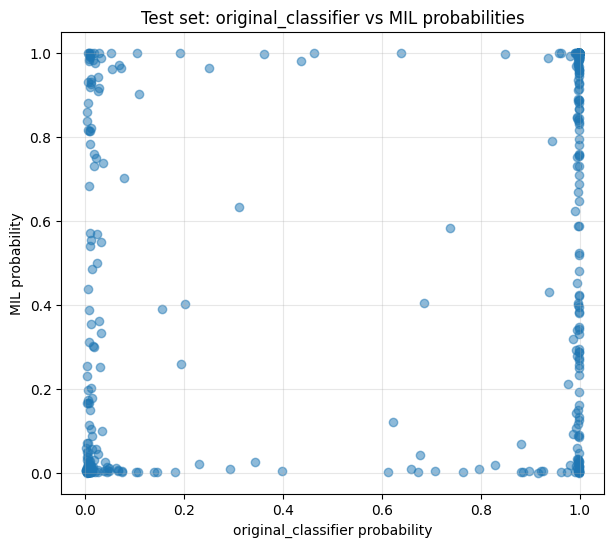

Saved: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/evaluation/mil/mil_classifier_evaluation_plots/paired_comparison_cases_by_split.png


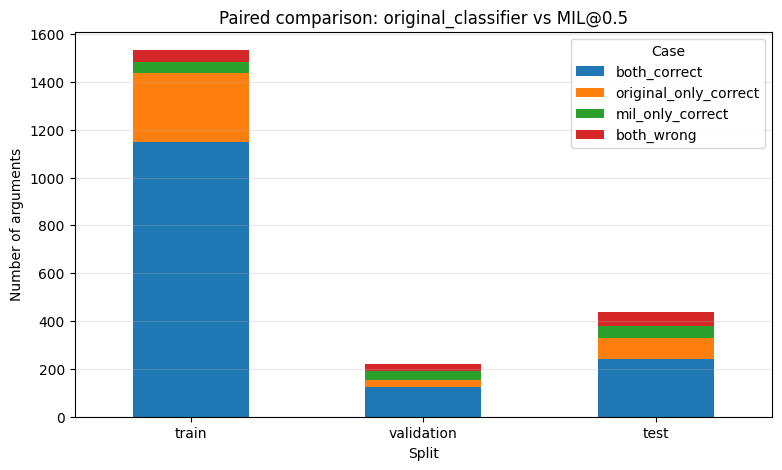

Saved: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/evaluation/mil/mil_classifier_evaluation_plots/test_probability_histograms_original_classifier_vs_mil.png


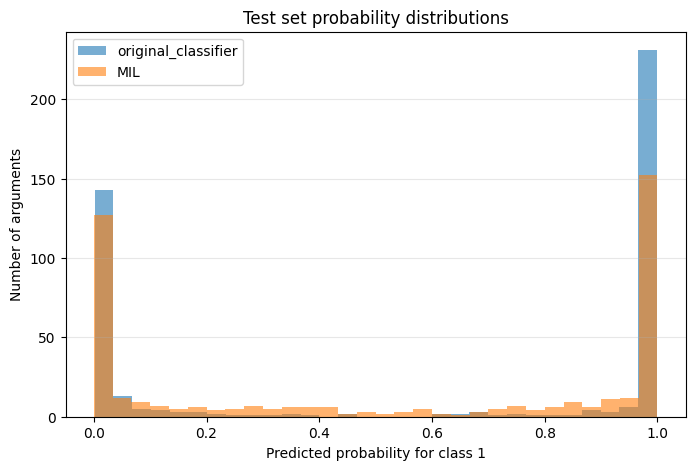

In [12]:
# Probability scatter on test.
test_eval_df = eval_df[eval_df["split"] == "test"].copy()

plt.figure(figsize=(7, 6))
plt.scatter(
    test_eval_df["original_classifier_probability"],
    test_eval_df["mil_probability"],
    alpha=0.5,
)
plt.xlabel("original_classifier probability")
plt.ylabel("MIL probability")
plt.title("Test set: original_classifier vs MIL probabilities")
plt.grid(alpha=0.3)
save_current_plot("test_probability_scatter_original_classifier_vs_mil.png")

# Paired comparison as bar chart.
paired_plot_df = paired_df[paired_df["split"].isin(split_order)].copy()
paired_plot_df = paired_plot_df.set_index("split").reindex(split_order)

case_cols = [
    "both_correct",
    "original_only_correct",
    "mil_only_correct",
    "both_wrong",
]

ax = paired_plot_df[case_cols].plot(kind="bar", stacked=True, figsize=(9, 5))
ax.set_xlabel("Split")
ax.set_ylabel("Number of arguments")
ax.set_title("Paired comparison: original_classifier vs MIL@0.5")
ax.legend(title="Case")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
save_current_plot("paired_comparison_cases_by_split.png")

# Probability histograms on test.
plt.figure(figsize=(8, 5))
plt.hist(test_eval_df["original_classifier_probability"], bins=30, alpha=0.6, label="original_classifier")
plt.hist(test_eval_df["mil_probability"], bins=30, alpha=0.6, label="MIL")
plt.xlabel("Predicted probability for class 1")
plt.ylabel("Number of arguments")
plt.title("Test set probability distributions")
plt.legend()
plt.grid(axis="y", alpha=0.3)
save_current_plot("test_probability_histograms_original_classifier_vs_mil.png")


## 12. Compact test-set report

This cell prints and saves the most thesis-relevant test-set results.


In [13]:
test_metrics = metrics_df[metrics_df["split"] == "test"].copy()
test_confusion = confusion_df[confusion_df["split"] == "test"].copy()
test_pairwise = paired_df[paired_df["split"] == "test"].copy()

print("Test metrics:")
display(test_metrics)

print("\nTest confusion matrices:")
display(test_confusion)

print("\nTest paired comparison:")
display(test_pairwise)

TEST_REPORT_PATH = TABLE_DIR / "compact_test_report.csv"
test_metrics.to_csv(TEST_REPORT_PATH, index=False)
print("Saved:", TEST_REPORT_PATH)


Test metrics:


,split,method,n,positive_support,negative_support,predicted_positive_rate,accuracy,precision,recall,f1,roc_auc,average_precision,brier_score,threshold
4,test,original_classifier,438,225,213,0.586758,0.748858,0.723735,0.826667,0.771784,0.785874,0.748761,0.239249,0.5
5,test,MIL@0.5,438,225,213,0.520548,0.668950,0.675439,0.684444,0.679912,0.741158,0.786906,0.272393,0.5



Test confusion matrices:


,split,method,tn,fp,fn,tp,n
4,test,original_classifier,142,71,39,186,438
5,test,MIL@0.5,139,74,71,154,438



Test paired comparison:


,split,n,both_correct,original_only_correct,mil_only_correct,both_wrong,both_correct_rate,original_only_correct_rate,mil_only_correct_rate,both_wrong_rate
2,test,438,243,85,50,60,0.554795,0.194064,0.114155,0.136986


Saved: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/evaluation/mil/mil_classifier_evaluation_tables/compact_test_report.csv


## 13. Interpretation notes

Use this notebook mainly to answer the following questions:

1. Does the MIL model reproduce document-level ground-truth labels at all?
2. How far is MIL from the original classifier as a document-level classifier?
3. Are there original-classifier false negatives or false positives that MIL handles differently?
4. Is the MIL score useful as a classifier score, or mainly as a span-ranking signal?

For the thesis, keep the distinction clear: strong document-level MIL performance is helpful, but it does not prove that the selected spans are good explanations. Span quality still needs to be evaluated separately through perturbation, masked token ratio, and qualitative inspection.
